## 2. Recreating IMSIP6 total BMB melting

This note book recreates the basal melting figure as submitted in the official paper (credit to Helene Seroussi). Additionally we load a table and group the result by average melting in 2100, 2200 and 2300 and and melt parameterization.

In [4]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n

import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalars'


In [5]:
df = pd.read_csv('metadata.txt', usecols=[1,2,3,4,5,6,7,8,9])
df['melt2100'] = 0
df['melt2200'] = 0
df['melt2300'] = 0
df

,Climate Forcing,Experiment,GL Melt,Group,Main submission,Melt Parameterisation,Model,Model setup,fileID,melt2100,melt2200,melt2300
0,CCSM4,expAE02,Sub-Grid,DC,1.0,Quad. Non-local,ISSM,DC\_ISSM,DC_ISSM,0,0,0
1,HadGEM2,expAE03,Sub-Grid,DC,1.0,Quad. Non-local,ISSM,DC\_ISSM,DC_ISSM,0,0,0
2,CESM2,expAE04,Sub-Grid,DC,1.0,Quad. Non-local,ISSM,DC\_ISSM,DC_ISSM,0,0,0
3,UKESM,expAE05,Sub-Grid,DC,1.0,Quad. Non-local,ISSM,DC\_ISSM,DC_ISSM,0,0,0
4,CCSM4,expAE02,Floating condition,DOE,1.0,Quad. Non-local,MALI,DOE\_MALI\_4km,DOE_MALI_4km,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
167,UKESM,expAE05,Yes,VUW,0.0,Lin,PISM,VUW\_PISM2\_s3,VUW_PISM2_s3,0,0,0
168,CCSM4,expAE02,Yes,VUW,0.0,Lin,PISM,VUW\_PISM2\_s4,VUW_PISM2_s4,0,0,0
169,HadGEM2,expAE03,Yes,VUW,0.0,Lin,PISM,VUW\_PISM2\_s4,VUW_PISM2_s4,0,0,0
170,CESM2,expAE04,Yes,VUW,0.0,Lin,PISM,VUW\_PISM2\_s4,VUW_PISM2_s4,0,0,0


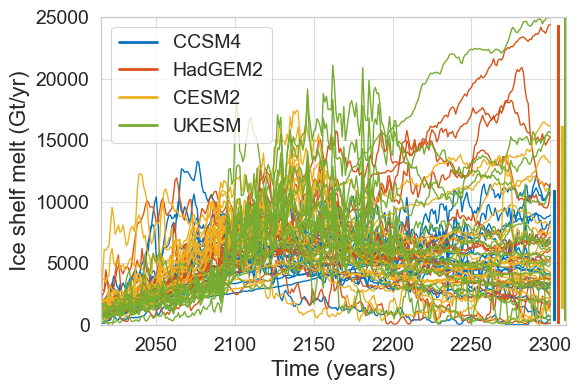

In [7]:
time = np.arange(2016, 2301)
i_2100= np.argwhere(time == 2091)[0][0]
i_2200= np.argwhere(time == 2191)[0][0]
i_2300= np.argwhere(time == 2291)[0][0]



expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
expnames_plot = ['CCSM4','HadGEM2','CESM2','UKESM']

# Create a dictionary to store the lists
valuesend_dict = {expname: [] for expname in expnames}
dic_all = {}

colors = np.array([[0, 0.4470, 0.7410], [0.8500, 0.3250, 0.0980], [0.9290, 0.6940, 0.1250], [0.4660, 0.6740, 0.1880]])

f,ax = plt.subplots(1,1, figsize = (6,4))

# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    dic_climateforcing = {}
    file_exp = os.listdir(f"{computed_name}/{expname}/shelfmelt")
    file_exp = [file for file in file_exp if len(file) >= 3]

    for ifile in reversed(range(len(file_exp))):
        if len(file_exp[ifile]) < 3:
            del file_exp[ifile]

    for ifile in range(len(file_exp)):
        filename = f"{computed_name}/{expname}/shelfmelt/{file_exp[ifile]}"
        d = xr.open_dataset(filename,decode_times=False )
        data = d.shelfmelt.values * 365.25 * 24 * 3600 / 10**12
#         time = d.time
      

     

        if ("NORCE" in file_exp[ifile] and "NORCE_CISM3-MAR364-ERA-t1-non" not in file_exp[ifile]) or \
           ("VUW" in file_exp[ifile] and "VUW_PISM1_e" not in file_exp[ifile]) or \
           ("DOE" in file_exp[ifile] and "DOE_MALI_4km" not in file_exp[ifile]) or \
           ("NCAR" in file_exp[ifile] and "NCAR_CISM2" not in file_exp[ifile]) or \
           ("LSCE" in file_exp[ifile] and "LSCE_GRISLI_e" not in file_exp[ifile]) or \
           ("ULB" in file_exp[ifile] and "ULB_fETISh-KoriBU1" not in file_exp[ifile]) or \
           ("IMAU" in file_exp[ifile] and "IMAU_UFEMISM1" not in file_exp[ifile]):
            pass
        else:
            modelrun = file_exp[ifile].split('AIS_')[-1].split(expname)[0]
            modelrun = modelrun[:-1]
            if len(data) > 250:

                if data[-1] > 0:
                    data = -data

                if -np.sum(data[:285]) > 4 * 10**6 or -np.sum(data[:285]) < 0:
                    print(filename)
                else:
                    valuesend_dict[expname].append(-data[time.size-1])
                    plt.plot(d.time, -(data[:d.time.size]), linewidth=1, color=colors[iexp, :])
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2100'] = -data[i_2100:i_2100+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2200'] = -data[i_2200:i_2200+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2300'] = -data[i_2300:i_2300+10].mean()
        
                    
            else:
                print("experiment too short for")
                
        dic_all[expname]=dic_climateforcing
        


for iexp, expname in enumerate(expnames):
    x = [2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp, 2303 + 2.5 * iexp]
    y = [np.min(valuesend_dict[expname]), np.max(valuesend_dict[expname]),
         np.max(valuesend_dict[expname]), np.min(valuesend_dict[expname])]
    plt.fill(x, y, [-1, -1, -1, -1], color=colors[iexp, :], edgecolor=colors[iexp, :])

ax.set_ylim([0, 2.5 * 10**4])
ax.set_xlabel('Time (years)', fontsize=16)
ax.set_ylabel('Ice shelf melt (Gt/yr)', fontsize=16)

legend_lines = [mlines.Line2D([], [], color=colors[i], linewidth=2, label=expname) for i, expname in enumerate(expnames_plot)]
ax.legend(handles=legend_lines, loc='upper left', fontsize=14)

# plt.legend(expnames, loc='upper left', fontsize=14)
# plt.text(1985, 0, 'b', verticalalignment='middle', horizontalalignment='right', fontsize=18, fontweight='b')
ax.set_xlim([2015, 2310])
# plt.gca().set_position([0.1300, 0.1100, 0.7750, 0.3812])
ax.tick_params(labelsize=14)
ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
# plt.savefig('Figures/SMB_BMB_2300forcing_onemember.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [8]:
df = df[df['melt2100'] != 0]
df

,Climate Forcing,Experiment,GL Melt,Group,Main submission,Melt Parameterisation,Model,Model setup,fileID,melt2100,melt2200,melt2300
0,CCSM4,expAE02,Sub-Grid,DC,1.0,Quad. Non-local,ISSM,DC\_ISSM,DC_ISSM,5267.172013,6325.497535,5381.871369
1,HadGEM2,expAE03,Sub-Grid,DC,1.0,Quad. Non-local,ISSM,DC\_ISSM,DC_ISSM,5956.232944,8043.897200,6855.585727
2,CESM2,expAE04,Sub-Grid,DC,1.0,Quad. Non-local,ISSM,DC\_ISSM,DC_ISSM,7423.270238,7425.641758,7528.363309
3,UKESM,expAE05,Sub-Grid,DC,1.0,Quad. Non-local,ISSM,DC\_ISSM,DC_ISSM,3718.047787,9521.244563,6826.355576
4,CCSM4,expAE02,Floating condition,DOE,1.0,Quad. Non-local,MALI,DOE\_MALI\_4km,DOE_MALI_4km,7045.302754,6577.676486,10549.144590
...,...,...,...,...,...,...,...,...,...,...,...,...
131,UKESM,expAE05,NaN,VUB,1.0,Quad. Non-local,AISMPALEO,VUB\_AISMPALEO,VUB_AISMPALEO,2862.282291,7482.086862,563.132510
132,CCSM4,expAE02,No,VUW,1.0,Lin,PISM,VUW\_PISM1,VUW_PISM1,8624.356017,5146.633004,5185.664754
133,HadGEM2,expAE03,No,VUW,1.0,Lin,PISM,VUW\_PISM1,VUW_PISM1,9534.583336,6149.108382,5674.925793
134,CESM2,expAE04,No,VUW,1.0,Lin,PISM,VUW\_PISM1,VUW_PISM1,10268.361104,6249.222352,5223.098025


Text(0.5, 1.0, 'melt2300')

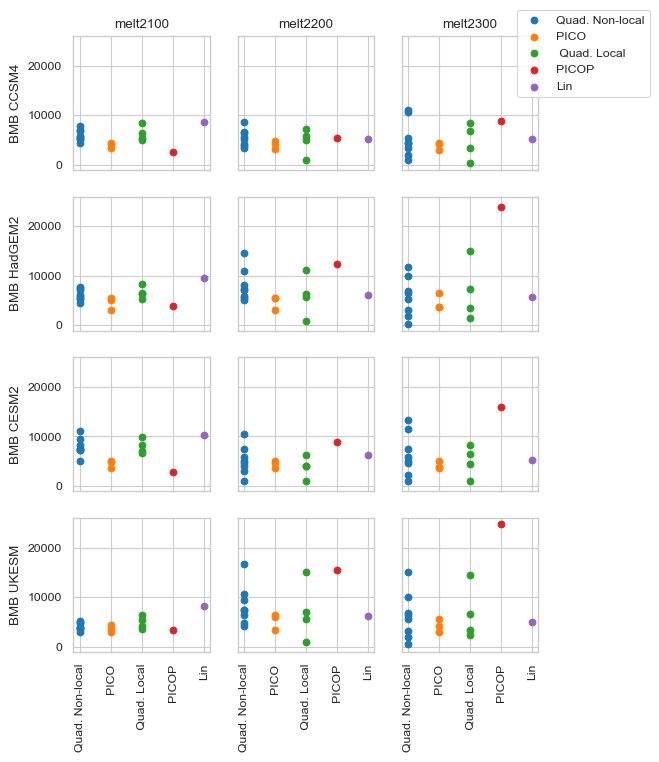

In [9]:

f,ax = plt.subplots(4,3, figsize = (6,8), sharey = True,sharex =True)

# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    df_climateforcing = df[(df['Experiment'] == expname)]
    unique_entries = df_climateforcing['Melt Parameterisation'].unique()
    for i, meltparam in enumerate(unique_entries):

        vals = df_climateforcing.loc[(df_climateforcing['Melt Parameterisation']==meltparam),'melt2100']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,0].scatter(x,vals.values,label  = meltparam)
        vals = df_climateforcing.loc[(df_climateforcing['Melt Parameterisation']==meltparam),'melt2200']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,1].scatter(x,vals.values,label  = meltparam)
        vals = df_climateforcing.loc[(df_climateforcing['Melt Parameterisation']==meltparam),'melt2300']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,2].scatter(x,vals.values,label  = meltparam)
    ax[iexp,0].set_ylabel('BMB '+ expnames_plot[iexp])
    ax[iexp,0].set_xticks(np.arange(0,len(unique_entries)))
    ax[iexp,0].set_xticklabels(unique_entries)
    ax[iexp,0].tick_params(axis='x', labelrotation=90) 
    ax[iexp,1].tick_params(axis='x', labelrotation=90) 
    ax[iexp,2].tick_params(axis='x', labelrotation=90) 
    

ax[0,2].legend(frameon = True,loc = 0,bbox_to_anchor=[0.8, 0.5])
ax[0,0].set_title('melt2100')
ax[0,1].set_title('melt2200')
ax[0,2].set_title('melt2300')

### WEST Antartica



Here we redo the figure but are only intersted in west antartica so  `d.shelfmelt_region_1.values`

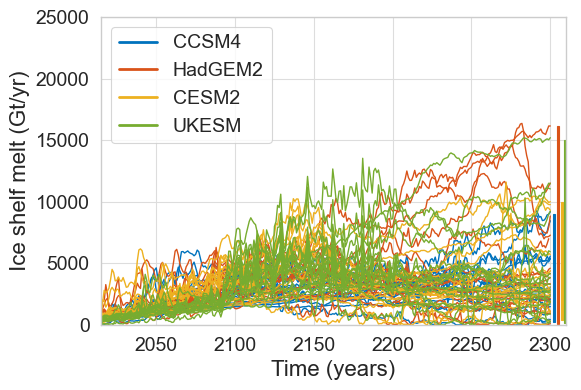

Text(0.5, 1.0, 'melt2300')

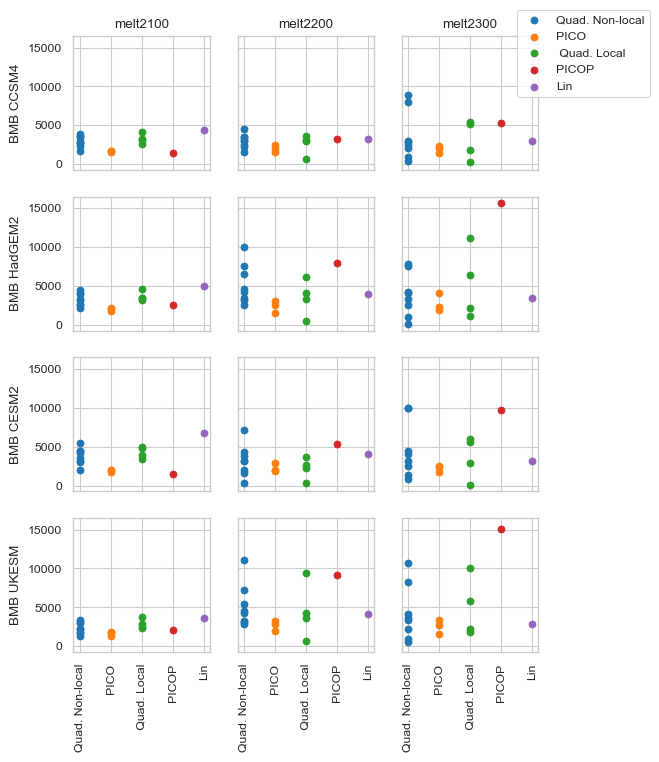

In [12]:


expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
expnames_plot = ['CCSM4','HadGEM2','CESM2','UKESM']

# Create a dictionary to store the lists
valuesend_dict = {expname: [] for expname in expnames}
dic_all = {}

colors = np.array([[0, 0.4470, 0.7410], [0.8500, 0.3250, 0.0980], [0.9290, 0.6940, 0.1250], [0.4660, 0.6740, 0.1880]])

f,ax = plt.subplots(1,1, figsize = (6,4))

# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    dic_climateforcing = {}
    file_exp = os.listdir(f"{computed_name}/{expname}/shelfmelt")
    file_exp = [file for file in file_exp if len(file) >= 3]

    for ifile in reversed(range(len(file_exp))):
        if len(file_exp[ifile]) < 3:
            del file_exp[ifile]

    for ifile in range(len(file_exp)):
        filename = f"{computed_name}/{expname}/shelfmelt/{file_exp[ifile]}"
        d = xr.open_dataset(filename,decode_times=False )
        data = d.shelfmelt_region_1.values * 365.25 * 24 * 3600 / 10**12
#         time = d.time
        time = np.arange(2016, 2301)

     

        if ("NORCE" in file_exp[ifile] and "NORCE_CISM3-MAR364-ERA-t1-non" not in file_exp[ifile]) or \
           ("VUW" in file_exp[ifile] and "VUW_PISM1_e" not in file_exp[ifile]) or \
           ("DOE" in file_exp[ifile] and "DOE_MALI_4km" not in file_exp[ifile]) or \
           ("NCAR" in file_exp[ifile] and "NCAR_CISM2" not in file_exp[ifile]) or \
           ("LSCE" in file_exp[ifile] and "LSCE_GRISLI_e" not in file_exp[ifile]) or \
           ("ULB" in file_exp[ifile] and "ULB_fETISh-KoriBU1" not in file_exp[ifile]) or \
           ("IMAU" in file_exp[ifile] and "IMAU_UFEMISM1" not in file_exp[ifile]):
            pass
        else:
            modelrun = file_exp[ifile].split('AIS_')[-1].split(expname)[0]
            modelrun = modelrun[:-1]
            if len(data) > 250:

                if data[-1] > 0:
                    data = -data

                if -np.sum(data[:285]) > 4 * 10**6 or -np.sum(data[:285]) < 0:
                    print(filename)
                else:
                    valuesend_dict[expname].append(-data[time.size-1])
                    plt.plot(d.time, -(data[:d.time.size]), linewidth=1, color=colors[iexp, :])
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2100'] = -data[i_2100:i_2100+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2200'] = -data[i_2200:i_2200+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2300'] = -data[i_2300:i_2300+10].mean()
      
            else:
                print("experiment too short for")
                
        dic_all[expname]=dic_climateforcing
        


for iexp, expname in enumerate(expnames):
    x = [2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp, 2303 + 2.5 * iexp]
    y = [np.min(valuesend_dict[expname]), np.max(valuesend_dict[expname]),
         np.max(valuesend_dict[expname]), np.min(valuesend_dict[expname])]
    plt.fill(x, y, [-1, -1, -1, -1], color=colors[iexp, :], edgecolor=colors[iexp, :])

ax.set_ylim([0, 2.5 * 10**4])
ax.set_xlabel('Time (years)', fontsize=16)
ax.set_ylabel('Ice shelf melt (Gt/yr)', fontsize=16)

legend_lines = [mlines.Line2D([], [], color=colors[i], linewidth=2, label=expname) for i, expname in enumerate(expnames_plot)]
ax.legend(handles=legend_lines, loc='upper left', fontsize=14)

# plt.legend(expnames, loc='upper left', fontsize=14)
# plt.text(1985, 0, 'b', verticalalignment='middle', horizontalalignment='right', fontsize=18, fontweight='b')
ax.set_xlim([2015, 2310])
# plt.gca().set_position([0.1300, 0.1100, 0.7750, 0.3812])
ax.tick_params(labelsize=14)
ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
# plt.savefig('Figures/SMB_BMB_2300forcing_onemember.pdf', format='pdf', bbox_inches='tight')
plt.show()


df = df[df['melt2100'] != 0]
df


f,ax = plt.subplots(4,3, figsize = (6,8), sharey = True,sharex =True)

# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    df_climateforcing = df[(df['Experiment'] == expname)]
    unique_entries = df_climateforcing['Melt Parameterisation'].unique()
    for i, meltparam in enumerate(unique_entries):

        vals = df_climateforcing.loc[(df_climateforcing['Melt Parameterisation']==meltparam),'melt2100']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,0].scatter(x,vals.values,label  = meltparam)
        vals = df_climateforcing.loc[(df_climateforcing['Melt Parameterisation']==meltparam),'melt2200']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,1].scatter(x,vals.values,label  = meltparam)
        vals = df_climateforcing.loc[(df_climateforcing['Melt Parameterisation']==meltparam),'melt2300']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,2].scatter(x,vals.values,label  = meltparam)
    ax[iexp,0].set_ylabel('BMB '+ expnames_plot[iexp])
    ax[iexp,0].set_xticks(np.arange(0,len(unique_entries)))
    ax[iexp,0].set_xticklabels(unique_entries)
    ax[iexp,0].tick_params(axis='x', labelrotation=90) 
    ax[iexp,1].tick_params(axis='x', labelrotation=90) 
    ax[iexp,2].tick_params(axis='x', labelrotation=90) 
    

ax[0,2].legend(frameon = True,loc = 0,bbox_to_anchor=[0.8, 0.5])
ax[0,0].set_title('melt2100')
ax[0,1].set_title('melt2200')
ax[0,2].set_title('melt2300')

#### Est Antartica


Here we redo the figure but are only intersted in East Antartica so  `d.shelfmelt_region_2.values`

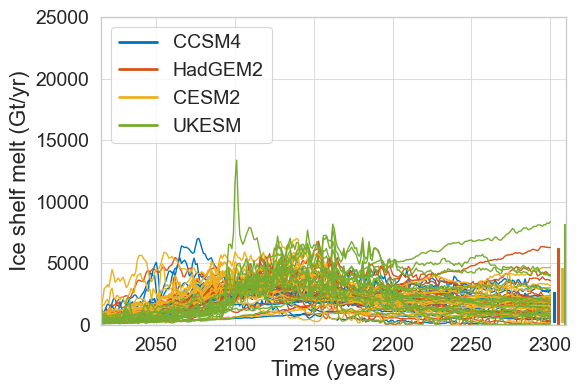

Text(0.5, 1.0, 'melt2300')

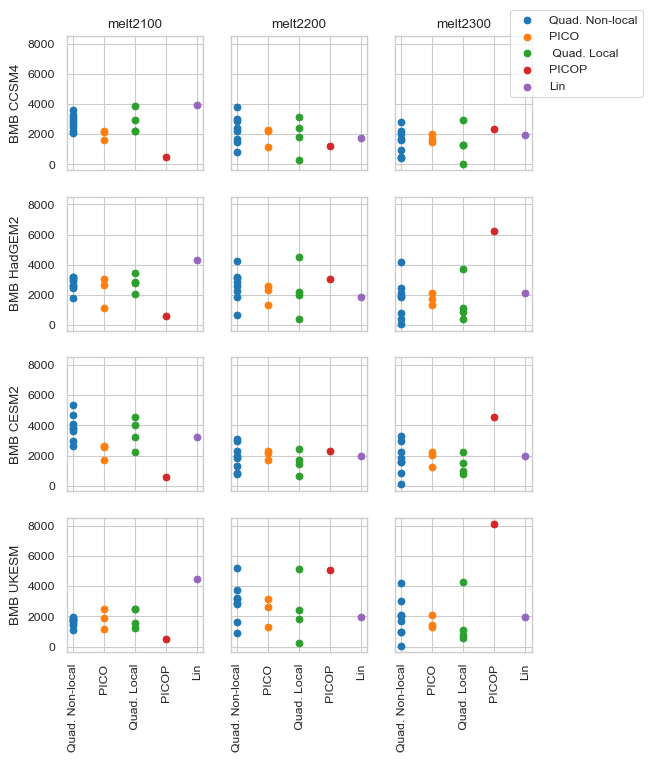

In [13]:


expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
expnames_plot = ['CCSM4','HadGEM2','CESM2','UKESM']

# Create a dictionary to store the lists
valuesend_dict = {expname: [] for expname in expnames}


colors = np.array([[0, 0.4470, 0.7410], [0.8500, 0.3250, 0.0980], [0.9290, 0.6940, 0.1250], [0.4660, 0.6740, 0.1880]])

f,ax = plt.subplots(1,1, figsize = (6,4))

# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    dic_climateforcing = {}
    file_exp = os.listdir(f"{computed_name}/{expname}/shelfmelt")
    file_exp = [file for file in file_exp if len(file) >= 3]

    for ifile in reversed(range(len(file_exp))):
        if len(file_exp[ifile]) < 3:
            del file_exp[ifile]

    for ifile in range(len(file_exp)):
        filename = f"{computed_name}/{expname}/shelfmelt/{file_exp[ifile]}"
        d = xr.open_dataset(filename,decode_times=False )
        data = d.shelfmelt_region_2.values * 365.25 * 24 * 3600 / 10**12
#         time = d.time
        time = np.arange(2016, 2301)

     

        if ("NORCE" in file_exp[ifile] and "NORCE_CISM3-MAR364-ERA-t1-non" not in file_exp[ifile]) or \
           ("VUW" in file_exp[ifile] and "VUW_PISM1_e" not in file_exp[ifile]) or \
           ("DOE" in file_exp[ifile] and "DOE_MALI_4km" not in file_exp[ifile]) or \
           ("NCAR" in file_exp[ifile] and "NCAR_CISM2" not in file_exp[ifile]) or \
           ("LSCE" in file_exp[ifile] and "LSCE_GRISLI_e" not in file_exp[ifile]) or \
           ("ULB" in file_exp[ifile] and "ULB_fETISh-KoriBU1" not in file_exp[ifile]) or \
           ("IMAU" in file_exp[ifile] and "IMAU_UFEMISM1" not in file_exp[ifile]):
            pass
        else:
            modelrun = file_exp[ifile].split('AIS_')[-1].split(expname)[0]
            modelrun = modelrun[:-1]
            if len(data) > 250:

                if data[-1] > 0:
                    data = -data

                if -np.sum(data[:285]) > 4 * 10**6 or -np.sum(data[:285]) < 0:
                    print(filename)
                else:
                    valuesend_dict[expname].append(-data[time.size-1])
                    plt.plot(d.time, -(data[:d.time.size]), linewidth=1, color=colors[iexp, :])
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2100'] = -data[i_2100:i_2100+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2200'] = -data[i_2200:i_2200+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2300'] = -data[i_2300:i_2300+10].mean()
        
                
            else:
                print("experiment too short for")
                
        dic_all[expname]=dic_climateforcing
        


for iexp, expname in enumerate(expnames):
    x = [2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp, 2303 + 2.5 * iexp]
    y = [np.min(valuesend_dict[expname]), np.max(valuesend_dict[expname]),
         np.max(valuesend_dict[expname]), np.min(valuesend_dict[expname])]
    plt.fill(x, y, [-1, -1, -1, -1], color=colors[iexp, :], edgecolor=colors[iexp, :])

ax.set_ylim([0, 2.5 * 10**4])
ax.set_xlabel('Time (years)', fontsize=16)
ax.set_ylabel('Ice shelf melt (Gt/yr)', fontsize=16)

legend_lines = [mlines.Line2D([], [], color=colors[i], linewidth=2, label=expname) for i, expname in enumerate(expnames_plot)]
ax.legend(handles=legend_lines, loc='upper left', fontsize=14)

# plt.legend(expnames, loc='upper left', fontsize=14)
# plt.text(1985, 0, 'b', verticalalignment='middle', horizontalalignment='right', fontsize=18, fontweight='b')
ax.set_xlim([2015, 2310])
# plt.gca().set_position([0.1300, 0.1100, 0.7750, 0.3812])
ax.tick_params(labelsize=14)
ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
# plt.savefig('Figures/SMB_BMB_2300forcing_onemember.pdf', format='pdf', bbox_inches='tight')
plt.show()


df = df[df['melt2100'] != 0]
df


f,ax = plt.subplots(4,3, figsize = (6,8), sharey = True,sharex =True)

# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    df_climateforcing = df[(df['Experiment'] == expname)]
    unique_entries = df_climateforcing['Melt Parameterisation'].unique()
    for i, meltparam in enumerate(unique_entries):

        vals = df_climateforcing.loc[(df_climateforcing['Melt Parameterisation']==meltparam),'melt2100']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,0].scatter(x,vals.values,label  = meltparam)
        vals = df_climateforcing.loc[(df_climateforcing['Melt Parameterisation']==meltparam),'melt2200']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,1].scatter(x,vals.values,label  = meltparam)
        vals = df_climateforcing.loc[(df_climateforcing['Melt Parameterisation']==meltparam),'melt2300']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,2].scatter(x,vals.values,label  = meltparam)
    ax[iexp,0].set_ylabel('BMB '+ expnames_plot[iexp])
    ax[iexp,0].set_xticks(np.arange(0,len(unique_entries)))
    ax[iexp,0].set_xticklabels(unique_entries)
    ax[iexp,0].tick_params(axis='x', labelrotation=90) 
    ax[iexp,1].tick_params(axis='x', labelrotation=90) 
    ax[iexp,2].tick_params(axis='x', labelrotation=90) 
    

ax[0,2].legend(frameon = True,loc = 0,bbox_to_anchor=[0.8, 0.5])
ax[0,0].set_title('melt2100')
ax[0,1].set_title('melt2200')
ax[0,2].set_title('melt2300')